# Cell 1: Setup & Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Set a professional seaborn style
sns.set_theme(style='whitegrid')

# File paths
er_path = '/home/honganh/OOD/ts/time_series_project/data/processed/EldenRing_Final_Merged.csv'
ron_path = '/home/honganh/OOD/ts/time_series_project/data/processed/ReadyOrNot_Final_Merged.csv'

# Load both CSVs, parse Date as datetime, and set it as the index
games = {
    'Elden Ring': pd.read_csv(er_path, parse_dates=['Date'], index_col='Date'),
    'Ready Or Not': pd.read_csv(ron_path, parse_dates=['Date'], index_col='Date')
}

print('Data Loading Complete!')


Data Loading Complete!


# Cell 2: Data Quality & Summary Statistics

In [7]:
for game_name, df in games.items():
    print(f"\n{'='*40}")
    print(f"Data Quality & Summary for: {game_name}")
    print(f"{'='*40}")
    
    print("--- Missing Values (isnull().sum()) ---")
    print(df.isnull().sum())
    print("\n--- Summary Statistics (describe()) ---")
    display(df.describe())



Data Quality & Summary for: Elden Ring
--- Missing Values (isnull().sum()) ---
Avg_Player             0
Log_Player             0
Lag_Player             0
Discount_Ratio         0
Base_Price             0
Is_Weekend             0
Is_Holiday             0
Years_Since_Release    0
Trend_Index            0
Log_Twitch_Avg         0
Is_Major_Update        0
Is_Minor_Update        0
dtype: int64

--- Summary Statistics (describe()) ---


,Avg_Player,Log_Player,Lag_Player,Discount_Ratio,Base_Price,Is_Weekend,Is_Holiday,Years_Since_Release,Trend_Index,Log_Twitch_Avg,Is_Major_Update,Is_Minor_Update
count,1496.000000,1496.000000,1496.000000,1496.000000,1.496000e+03,1496.000000,1496.000000,1496.000000,1496.000000,1496.000000,1496.000000,1496.000000
mean,77955.512032,10.903741,10.905471,0.031964,5.999000e+01,0.286096,0.032086,2.050685,0.147567,8.914903,0.040775,0.008021
std,117676.172873,0.665998,0.668686,0.101521,7.107803e-15,0.452086,0.176286,1.183568,0.036947,0.981889,0.197836,0.089232
min,23082.000000,10.046852,10.046852,0.000000,5.999000e+01,0.000000,0.000000,0.002740,0.100000,3.465736,0.000000,0.000000
25%,35815.000000,10.486150,10.486150,0.000000,5.999000e+01,0.000000,0.000000,1.026712,0.120000,8.623173,0.000000,0.000000
50%,47350.500000,10.765353,10.767063,0.000000,5.999000e+01,0.000000,0.000000,2.050685,0.120000,8.961257,0.000000,0.000000
75%,65198.000000,11.085199,11.086866,0.000000,5.999000e+01,1.000000,0.000000,3.074658,0.160000,9.308997,0.000000,0.000000
max,953426.000000,13.767818,13.767818,0.400067,5.999000e+01,1.000000,1.000000,4.098630,0.680000,12.624796,1.000000,1.000000



Data Quality & Summary for: Ready Or Not
--- Missing Values (isnull().sum()) ---
Avg_Player             0
Log_Player             0
Lag_Player             0
Discount_Ratio         0
Base_Price             0
Is_Weekend             0
Is_Holiday             0
Years_Since_Release    0
Trend_Index            0
Log_Twitch_Avg         0
Is_Major_Update        0
Is_Minor_Update        0
dtype: int64

--- Summary Statistics (describe()) ---


,Avg_Player,Log_Player,Lag_Player,Discount_Ratio,Base_Price,Is_Weekend,Is_Holiday,Years_Since_Release,Trend_Index,Log_Twitch_Avg,Is_Major_Update,Is_Minor_Update
count,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000,1564.000000
mean,7842.713555,8.770761,8.770493,0.059482,43.509182,0.285806,0.034527,2.143836,0.137807,5.256815,0.029412,0.002558
std,6290.188045,0.584052,0.583692,0.138224,6.982953,0.451942,0.182636,1.237349,0.067660,1.184390,0.169012,0.050524
min,1848.000000,7.522400,7.522400,0.000000,35.990000,0.000000,0.000000,0.002740,0.020000,3.044522,0.000000,0.000000
25%,4187.750000,8.340158,8.340158,0.000000,35.990000,0.000000,0.000000,1.073288,0.080000,4.430817,0.000000,0.000000
50%,6144.000000,8.723394,8.723394,0.000000,49.990000,0.000000,0.000000,2.143836,0.160000,4.969813,0.000000,0.000000
75%,8917.500000,9.095883,9.095883,0.000000,49.990000,1.000000,0.000000,3.214384,0.200000,5.804374,0.000000,0.000000
max,55174.000000,10.918265,10.918265,0.500100,49.990000,1.000000,1.000000,4.284932,1.000000,10.409401,1.000000,1.000000


# Cell 3: Correlation Heatmap (Multicollinearity Check)

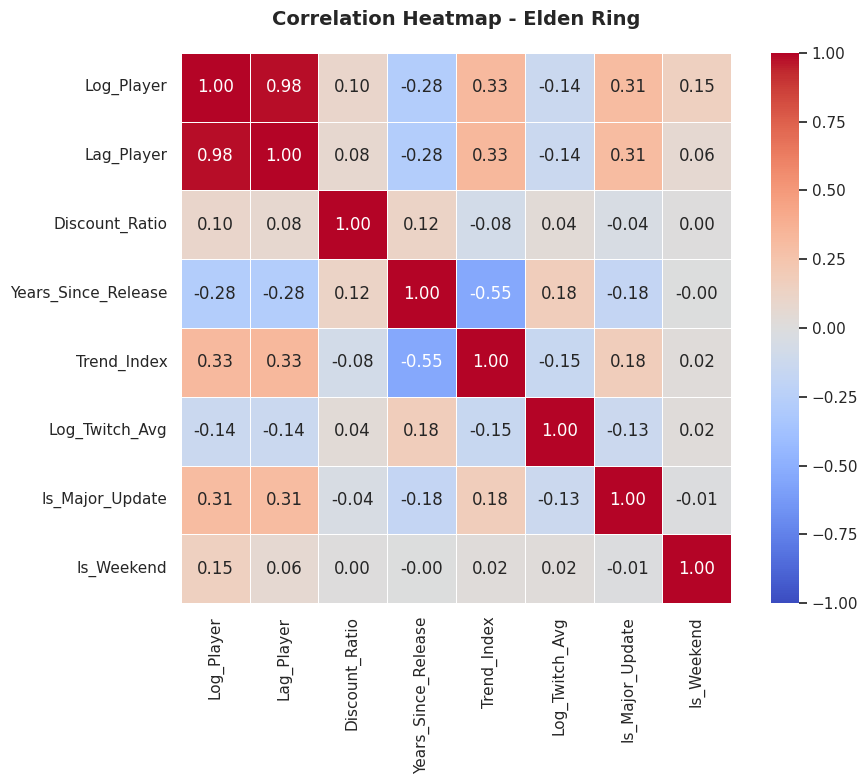

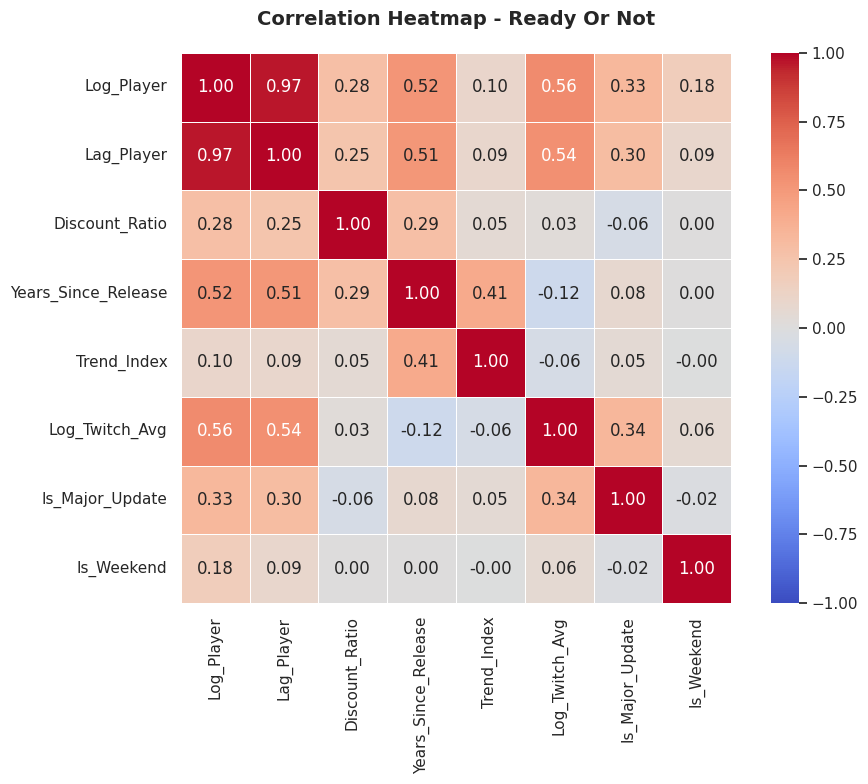

In [8]:
cols_to_corr = ['Log_Player', 'Lag_Player', 'Discount_Ratio', 'Years_Since_Release', 
                'Trend_Index', 'Log_Twitch_Avg', 'Is_Major_Update', 'Is_Weekend']

for game_name, df in games.items():
    # Maintain requested columns that exist in the dataframe
    valid_cols = [c for c in cols_to_corr if c in df.columns]
    if not valid_cols:
        continue
        
    corr_matrix = df[valid_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap='coolwarm', 
        vmin=-1, 
        vmax=1, 
        square=True, 
        linewidths=.5
    )
    plt.title(f'Correlation Heatmap - {game_name}', pad=20, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Cell 4: Dual-Axis Time Series Visualization (Storytelling)

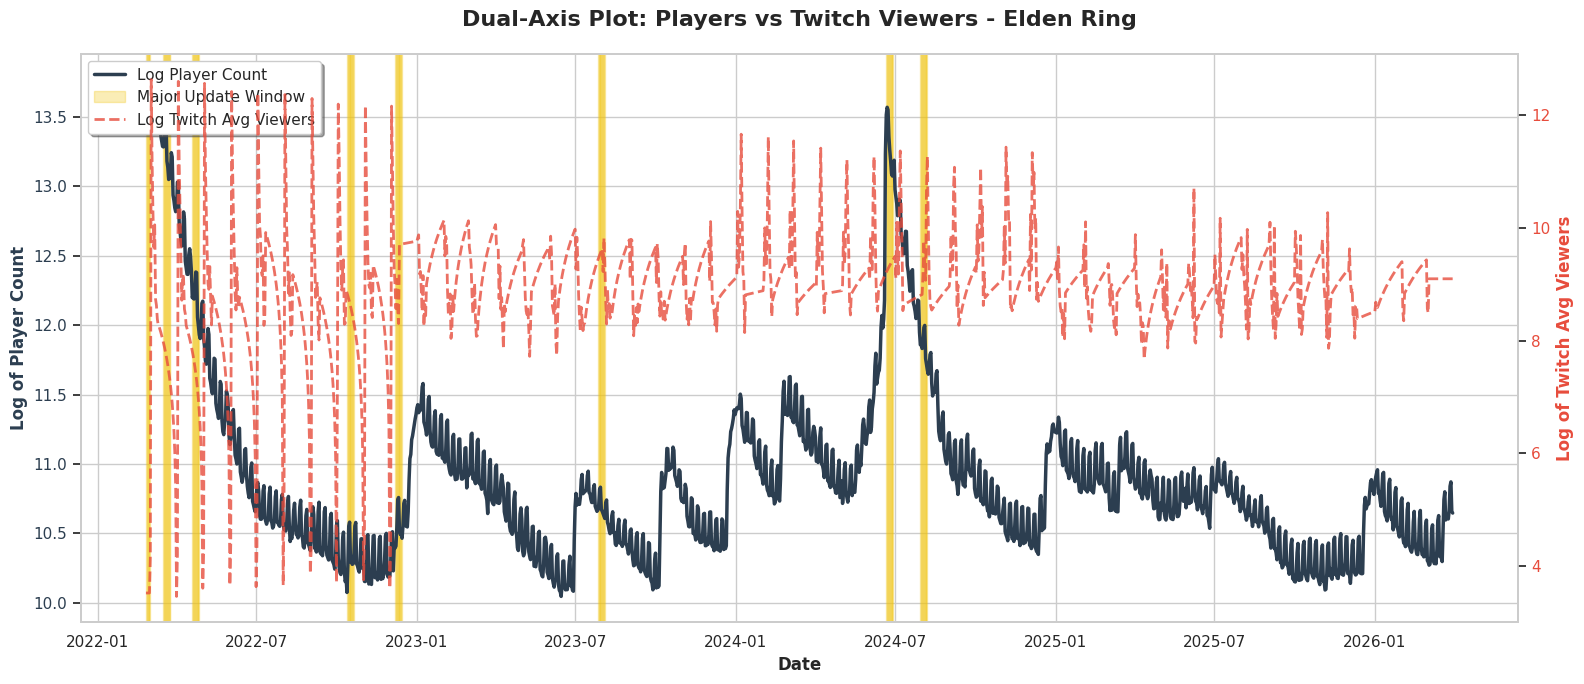

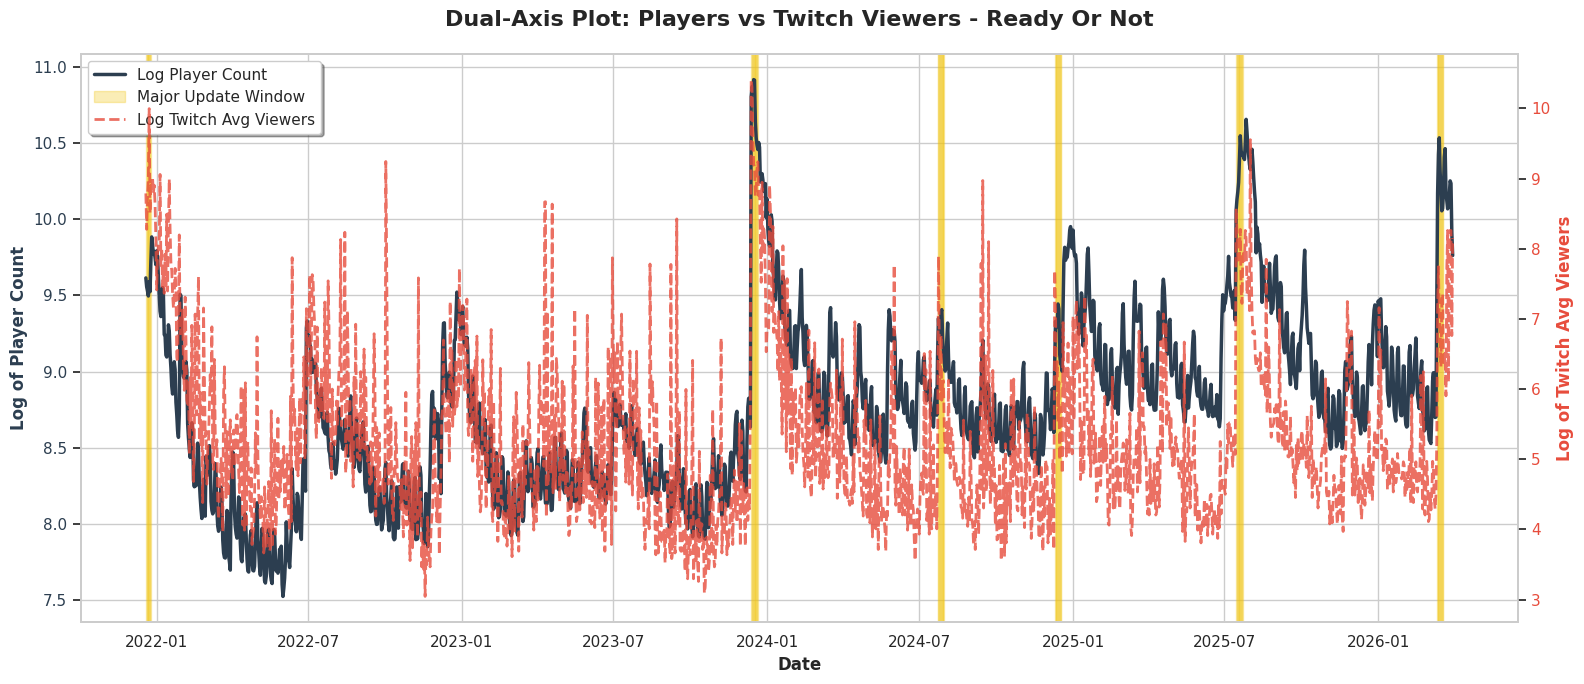

In [9]:
for game_name, df in games.items():
    fig, ax1 = plt.subplots(figsize=(16, 7))
    
    # --- Left Y-Axis: Log_Player ---
    color1 = '#2c3e50' # Dark Blue/Navy solid
    ax1.plot(df.index, df['Log_Player'], color=color1, linestyle='-', linewidth=2.5, label='Log Player Count')
    ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Log of Player Count', color=color1, fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color1)
    
    # --- Right Y-Axis: Log_Twitch_Avg ---
    ax2 = ax1.twinx()
    color2 = '#e74c3c' # Vibrant Red dashed
    ax2.plot(df.index, df['Log_Twitch_Avg'], color=color2, linestyle='--', linewidth=2, label='Log Twitch Avg Viewers', alpha=0.8)
    ax2.set_ylabel('Log of Twitch Avg Viewers', color=color2, fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # --- Shaded Regions for Major Updates ---
    if 'Is_Major_Update' in df.columns:
        is_update = df['Is_Major_Update'] == 1
        update_dates = df[is_update].index
        for i, dt in enumerate(update_dates):
            ax1.axvspan(
                dt, 
                dt + pd.Timedelta(days=1), 
                color='#f1c40f', 
                alpha=0.3, 
                label='Major Update Window' if i == 0 else ""
            )

    # Titles and Legends
    plt.title(f'Dual-Axis Plot: Players vs Twitch Viewers - {game_name}', fontsize=16, fontweight='bold', pad=20)
    
    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True, shadow=True)
    
    plt.grid(False) # Turn off automatic grid for dual-axis clarity
    plt.tight_layout()
    plt.show()


# Cell 5: Seasonality Diagnostics (ACF/PACF & Boxplots)

/tmp/ipykernel_2744822/776366727.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Weekend', y='Log_Player', ax=axes[2], palette='Set2')


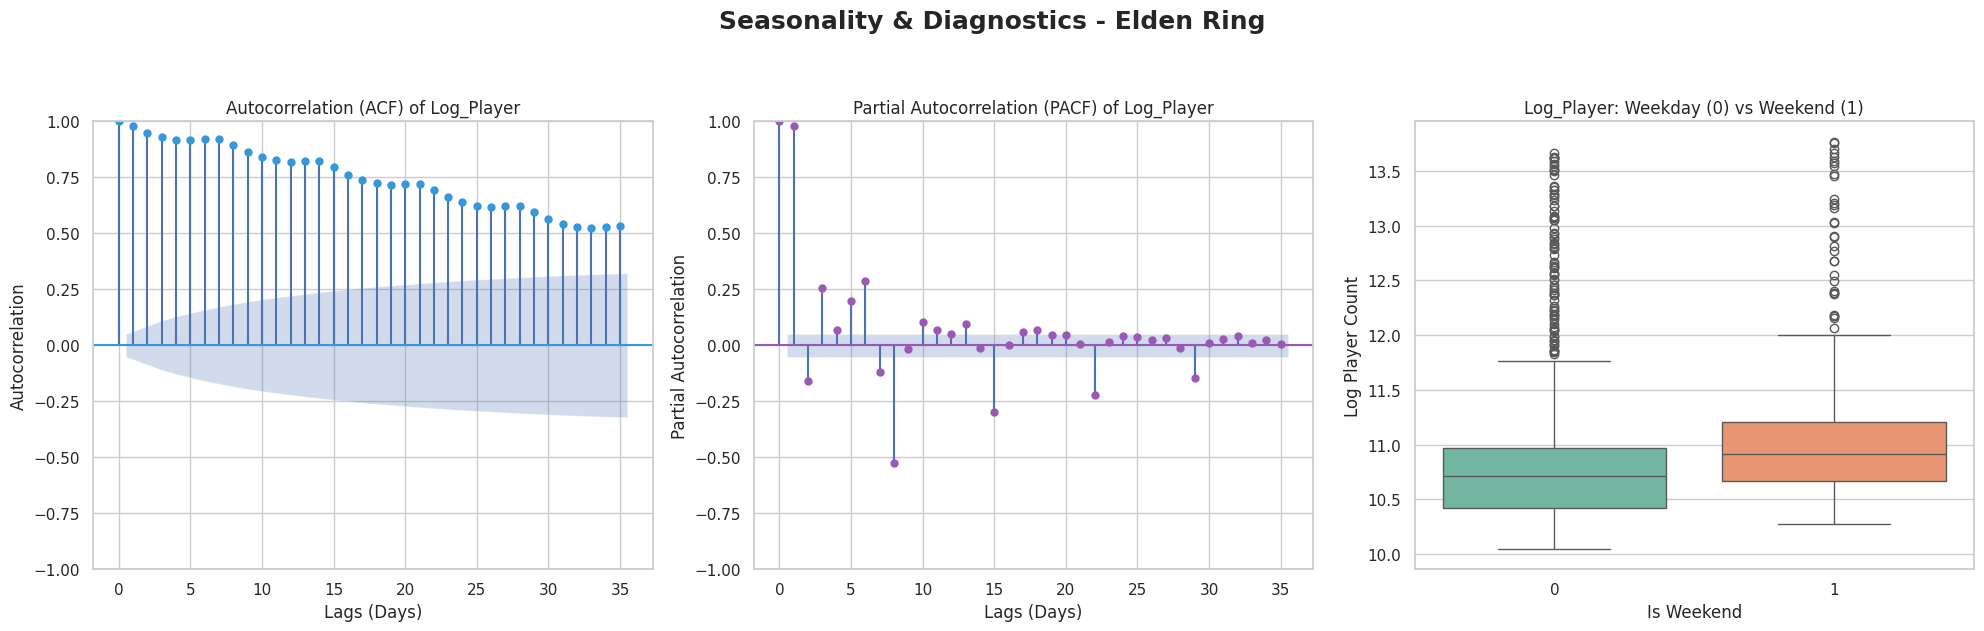

/tmp/ipykernel_2744822/776366727.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Weekend', y='Log_Player', ax=axes[2], palette='Set2')


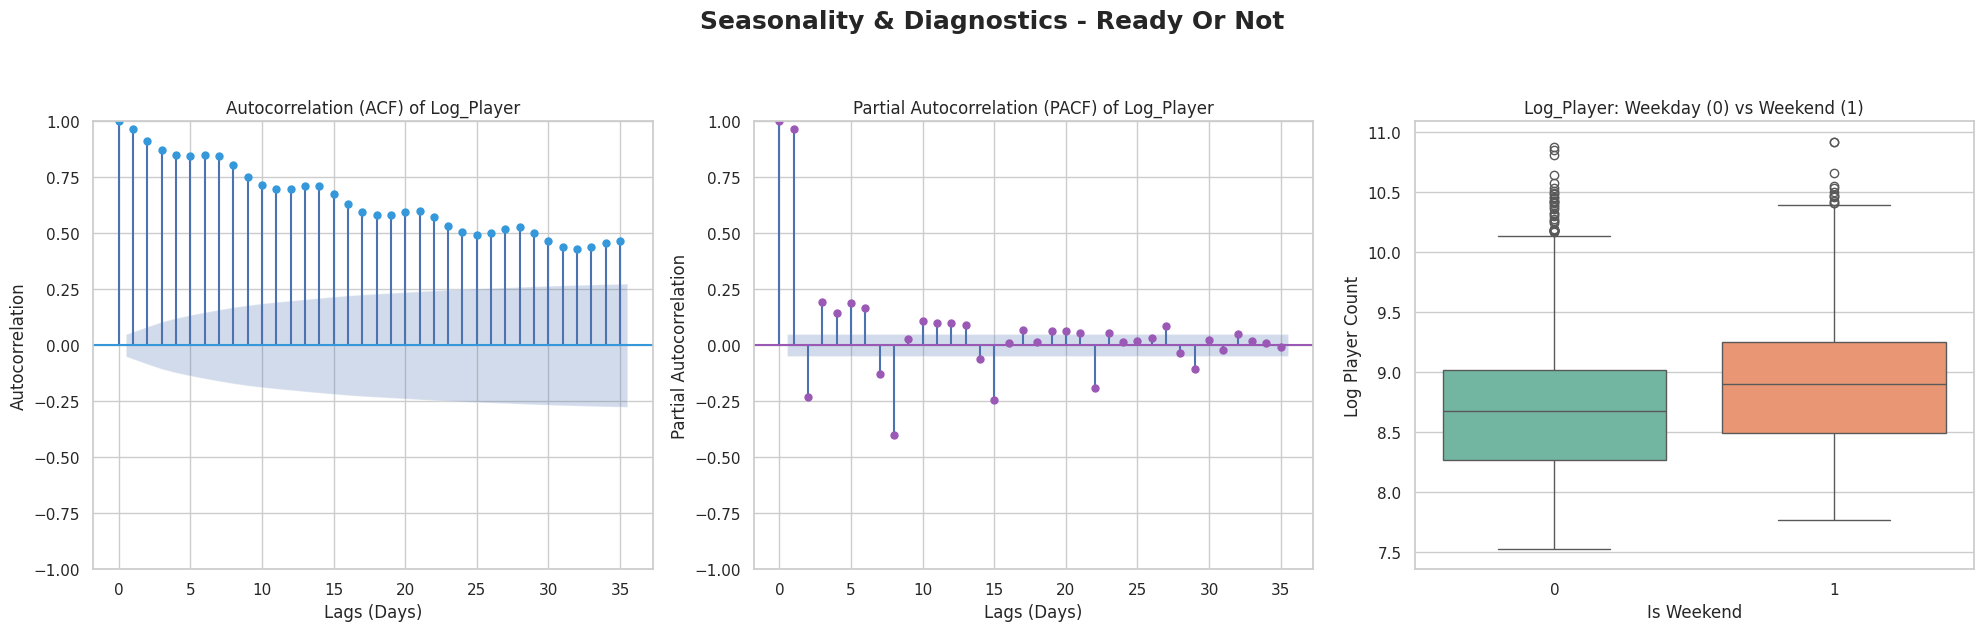

In [10]:
for game_name, df in games.items():
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # Drop NA to avoid ACF/PACF errors
    log_player_clean = df['Log_Player'].dropna()
    
    # --- Subplot 1: ACF of Log_Player ---
    plot_acf(log_player_clean, lags=35, ax=axes[0], title='Autocorrelation (ACF) of Log_Player', color='#3498db')
    axes[0].set_xlabel('Lags (Days)')
    axes[0].set_ylabel('Autocorrelation')
    
    # --- Subplot 2: PACF of Log_Player ---
    plot_pacf(log_player_clean, lags=35, ax=axes[1], title='Partial Autocorrelation (PACF) of Log_Player', color='#9b59b6', method='ywm')
    axes[1].set_xlabel('Lags (Days)')
    axes[1].set_ylabel('Partial Autocorrelation')
    
    # --- Subplot 3: Boxplot Is_Weekend vs Log_Player ---
    if 'Is_Weekend' in df.columns:
        sns.boxplot(data=df, x='Is_Weekend', y='Log_Player', ax=axes[2], palette='Set2')
        axes[2].set_title('Log_Player: Weekday (0) vs Weekend (1)')
        axes[2].set_xlabel('Is Weekend')
        axes[2].set_ylabel('Log Player Count')
    
    # General figure title
    fig.suptitle(f'Seasonality & Diagnostics - {game_name}', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
